# Breast Cancer Diagnosis — Explanatory Logistic Regression with and without PCA

**Dataset:** [Breast Cancer Wisconsin (Diagnostic)](https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/breast_cancer_data.csv) — 569 tumour samples, 30 numeric features derived from cell-nucleus measurements, binary target (`M` = malignant, `B` = benign).

**Goal:** Build and compare two explanatory logistic regression models using `statsmodels`:
1. **Raw features** — iterative VIF-based feature selection to remove multicollinearity before fitting.
2. **PCA components** — dimensionality reduction first, then logistic regression on the retained principal components.

Both models are evaluated for robustness via 5-fold cross-validation (ROC-AUC). The PCA model also includes a threshold-search step to maximise accuracy.

> **Note:** These are *explanatory* models — the objective is interpretability of coefficients (odds ratios), not predictive performance. No train/test split is applied; cross-validation is used solely to assess stability.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from pca import pca

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
seed = 99

## Dataset

**target**:
* _diagnosis_: M (malignant) or B (benign), target variable

**features**:
* _id_: patient identifier, no predictive value
* _radius_mean_: mean radius of cell nuclei
* _texture_mean_: mean texture (gray-scale variation)
* _perimeter_mean_: mean perimeter of cell nuclei
* _area_mean_: mean area of cell nuclei
* _smoothness_mean_: mean smoothness of the contour
* _compactness_mean_: mean compactness (perimeter² / area - 1)
* _concavity_mean_: mean severity of concave portions of the contour
* _concave_: ints_mean — mean number of concave points
* _symmetry_mean_: mean symmetry of cell nuclei
* _fractal_dimension_mean_: mean roughness of the contour
* _radius_se_: standard error of the radius
* _texture_se_: standard error of the texture
* _perimeter_se_: standard error of the perimeter
* _area_se_: standard error of the area
* _smoothness_se_: standard error of the smoothness
* _compactness_se_: standard error of the compactness
* _concavity_se_: standard error of the concavity
* _concave_: ints_se — standard error of the concave points
* _symmetry_se_: standard error of the symmetry
* _fractal_dimension_se_: standard error of the fractal dimension
* _radius_worst_: mean radius of the 3 largest cell nuclei
* _texture_worst_: texture of the 3 most extreme cell nuclei
* _perimeter_worst_: perimeter of the 3 most extreme cell nuclei
* _area_worst_: area of the 3 most extreme cell nuclei
* _smoothness_worst_: smoothness of the 3 most extreme cell nuclei
* _compactness_worst_: compactness of the 3 most extreme cell nuclei
* _concavity_worst_: concavity of the 3 most extreme cell nuclei
* _concave_: ints_worst — concave points of the 3 most extreme cell nuclei
* _symmetry_worst_: symmetry of the 3 most extreme cell nuclei
* _fractal_dimension_worst_: fractal dimension of the 3 most extreme cell nuclei

Features are grouped in three blocks: **mean**, **standard error**, and **worst** (average of the three largest values) for each of ten nucleus characteristics.

In [45]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/refs/heads/main/breast_cancer_data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [46]:
# Working copy — keeps the original intact for reference
df1 = df.copy()

# Drop uninformative columns
df1.drop(columns=['Unnamed: 32', 'id'], inplace=True)

In [47]:
df.shape

(569, 33)

## 1. Correlation & Multicollinearity Analysis
With 30 features derived from the same nucleus measurements across three statistical blocks (mean, SE, worst), high pairwise correlation and severe multicollinearity are expected from the outset.

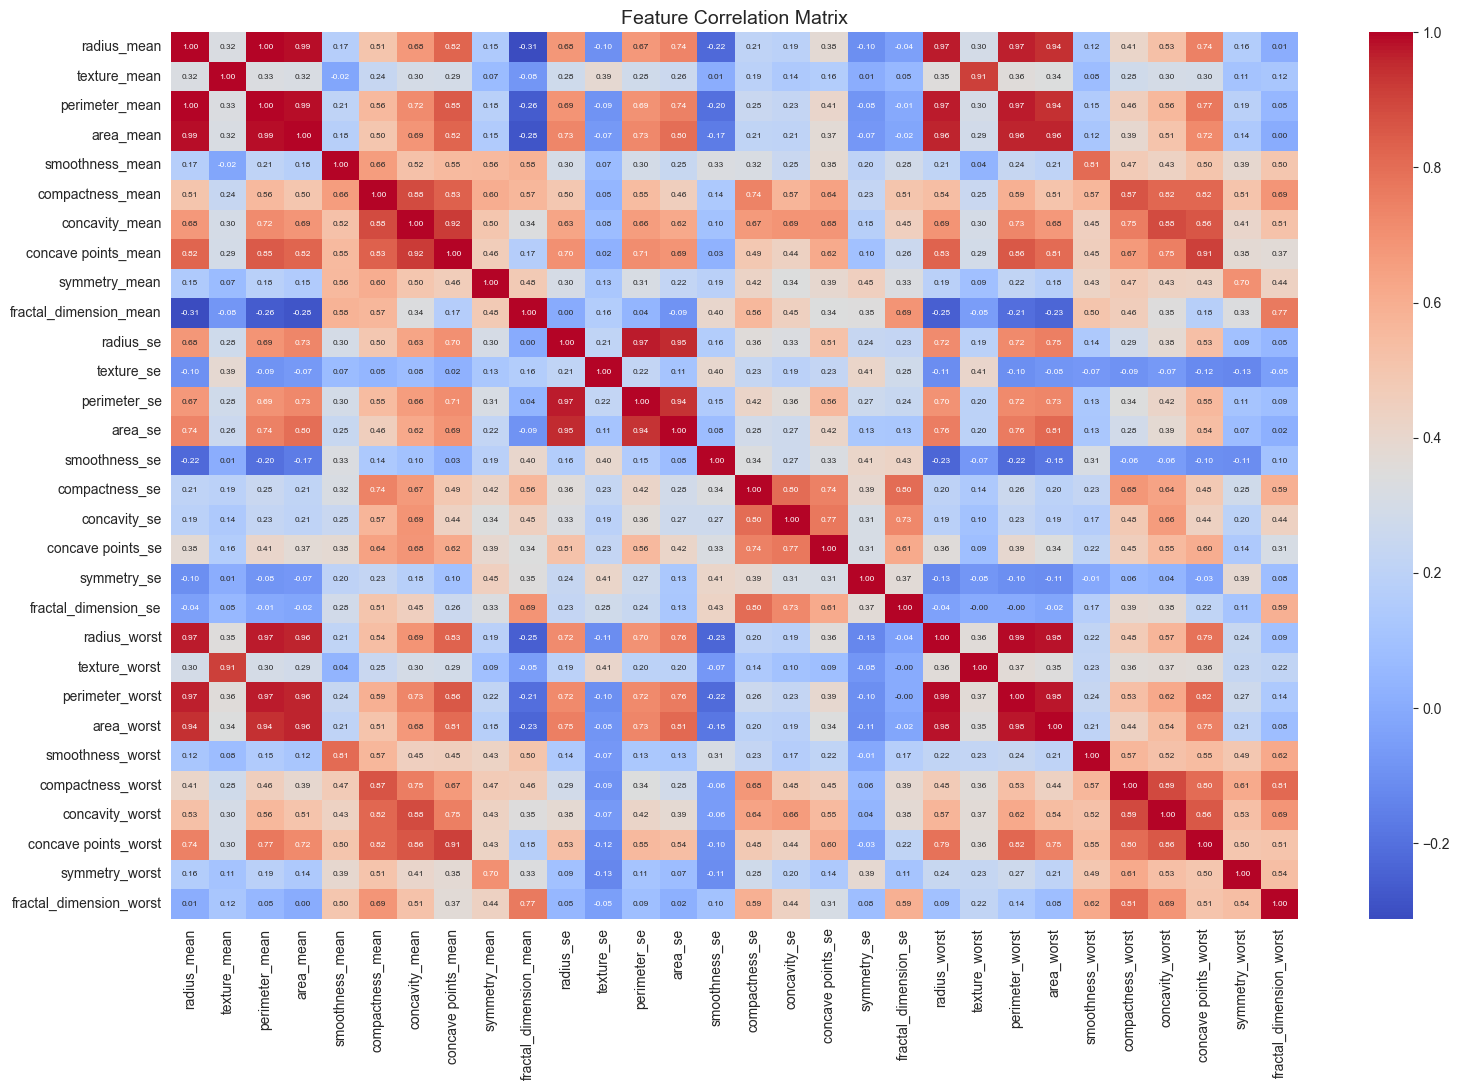

In [48]:
# Correlation heatmap
plt.figure(figsize=(16, 11))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 6})
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# The heatmap confirms strong collinearity across many feature pairs, especially within the size-related
# group (radius, perimeter, area)

In [49]:
# VIF for all numeric features
for ii, col in enumerate((df1.drop(columns='diagnosis')).columns):
    vif = variance_inflation_factor((df1.drop(columns='diagnosis')).values, ii)
    print(f"{col}: {vif:.2f}")

# All features exceed VIF = 10, confirming severe multicollinearity. The three size proxies (radius, perimeter, area) 
# are geometrically redundant — only one needs to be kept per block.

radius_mean: 63306.17
texture_mean: 251.05
perimeter_mean: 58123.59
area_mean: 1287.26
smoothness_mean: 393.40
compactness_mean: 200.98
concavity_mean: 157.86
concave points_mean: 154.24
symmetry_mean: 184.43
fractal_dimension_mean: 629.68
radius_se: 236.67
texture_se: 24.68
perimeter_se: 211.40
area_se: 72.47
smoothness_se: 26.17
compactness_se: 44.92
concavity_se: 33.24
concave points_se: 53.70
symmetry_se: 37.18
fractal_dimension_se: 27.53
radius_worst: 9674.74
texture_worst: 343.00
perimeter_worst: 4487.78
area_worst: 1138.76
smoothness_worst: 375.60
compactness_worst: 132.88
concavity_worst: 86.31
concave points_worst: 148.67
symmetry_worst: 218.92
fractal_dimension_worst: 423.40


## 2. Model A: Raw Features

### Preprocessing

In [50]:
# Encode target: Malignant = 1, Benign = 0
le = LabelEncoder()
df1['diagnosis'] = le.fit_transform(df1['diagnosis'])

X = df1.drop(columns=['diagnosis'])
y = df1['diagnosis']

# Standardise — required for VIF stability and coefficient comparability
scaler = StandardScaler()
df1_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

### Feature inspection

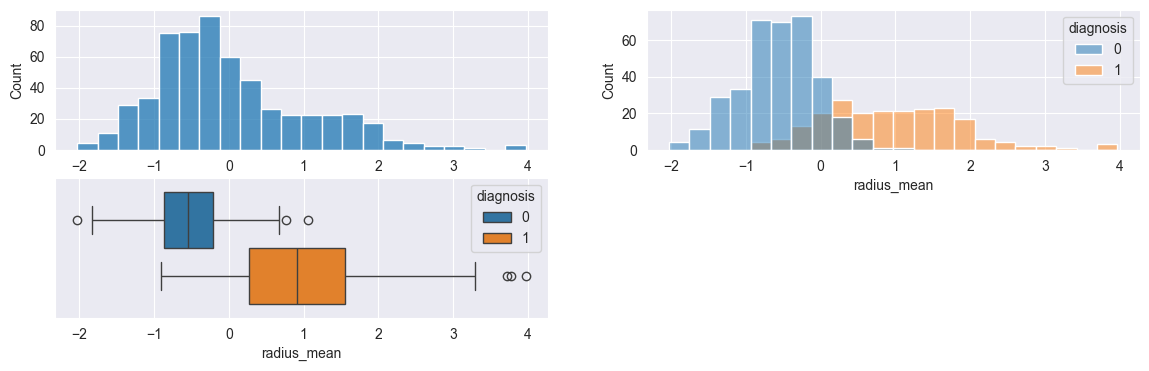

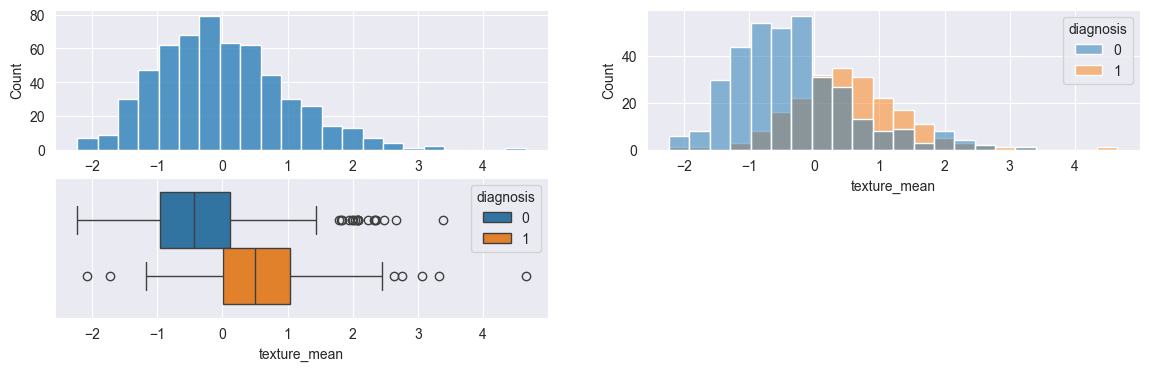

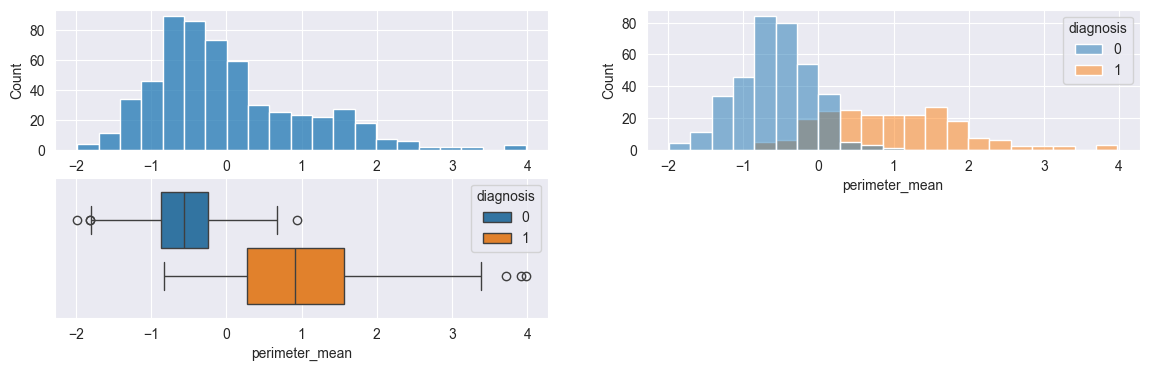

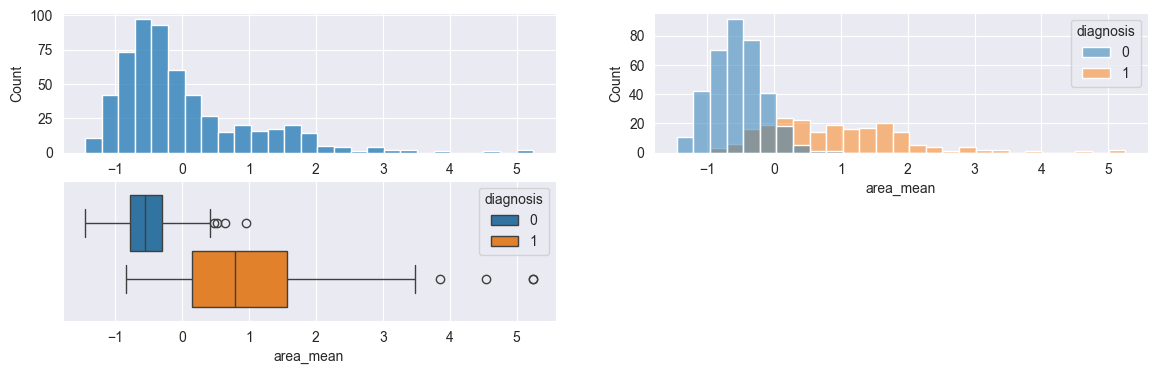

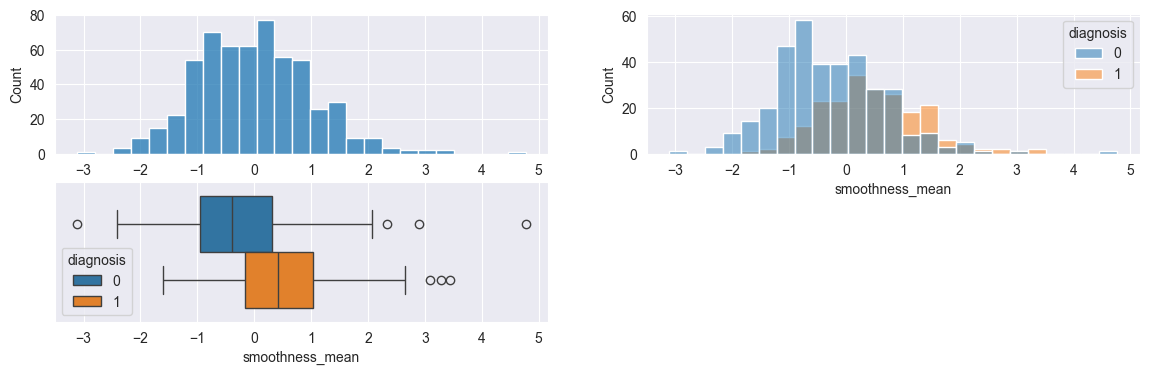

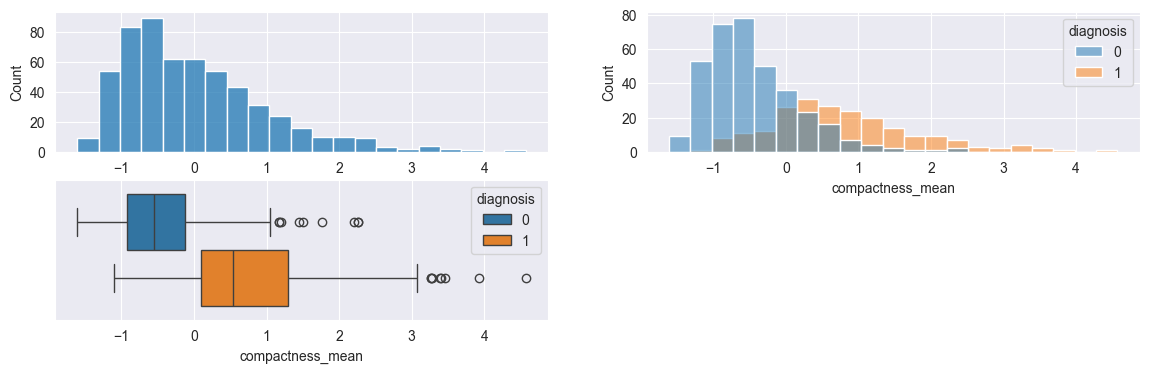

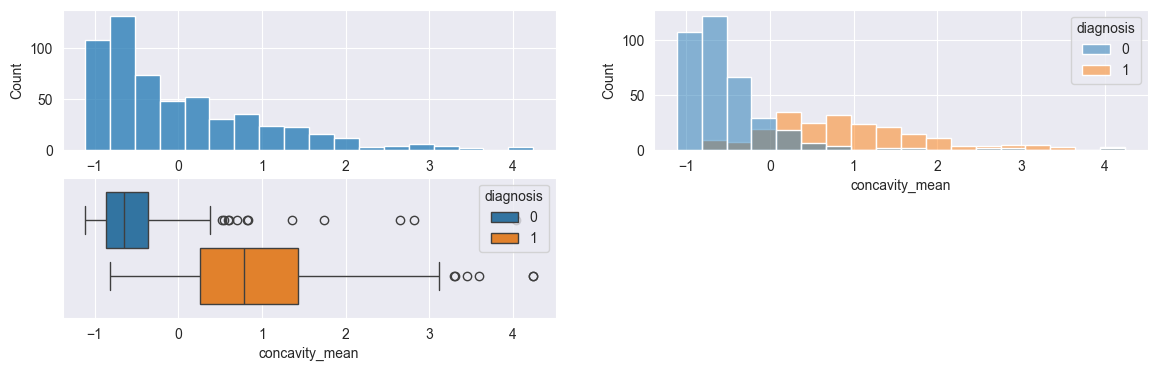

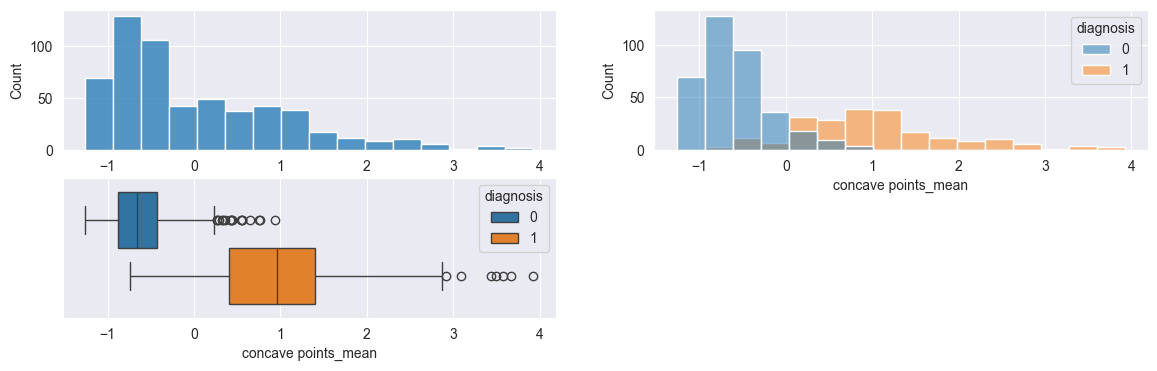

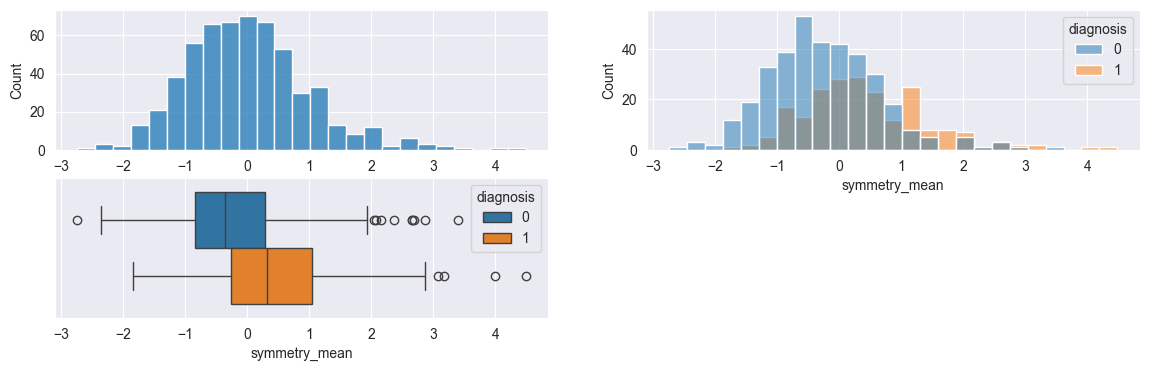

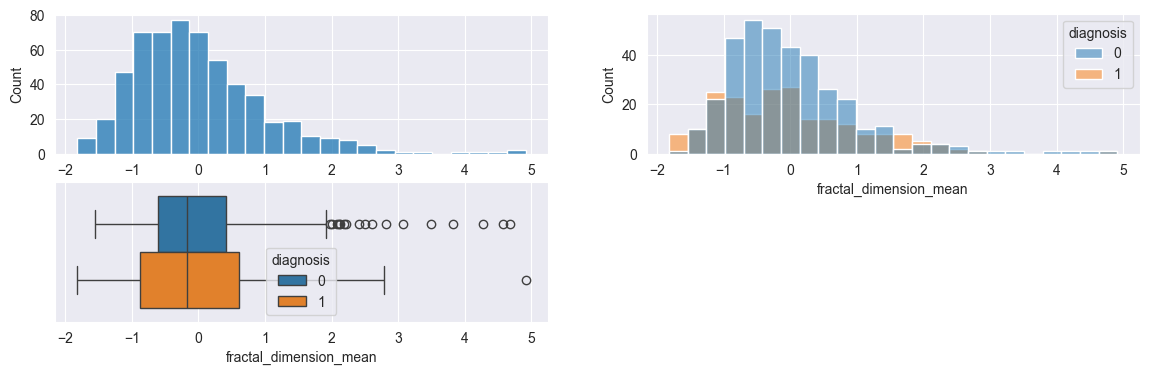

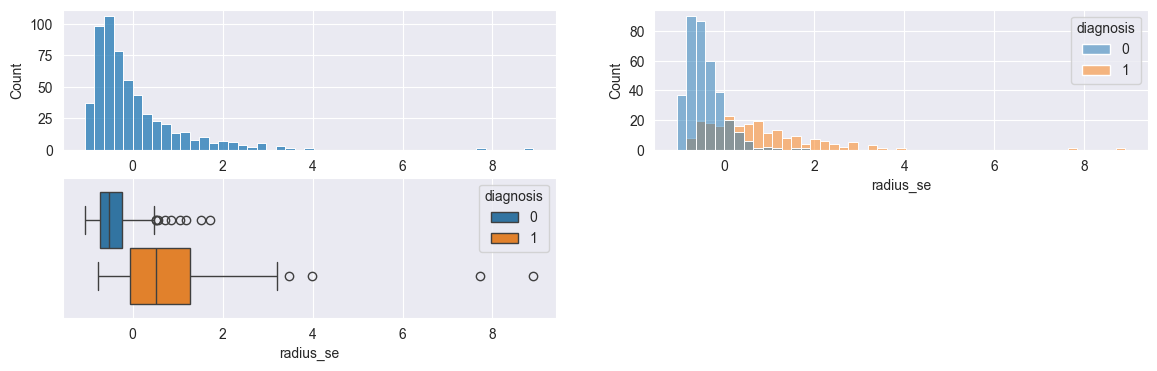

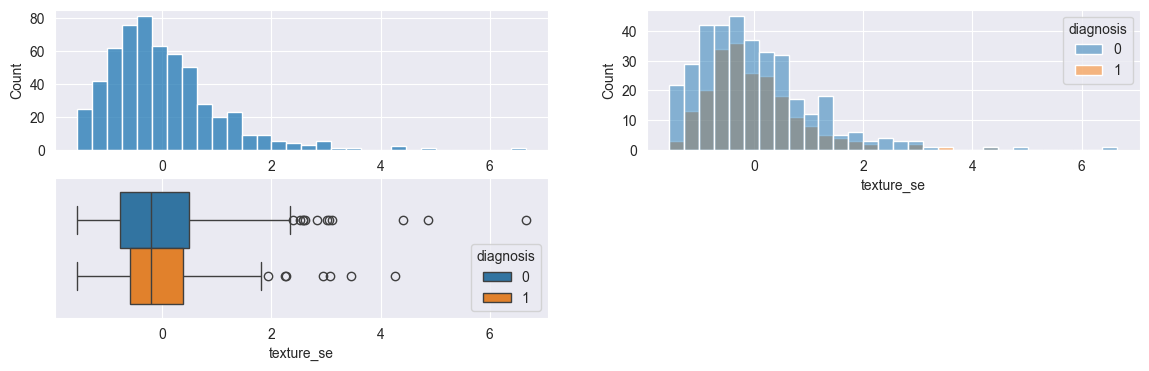

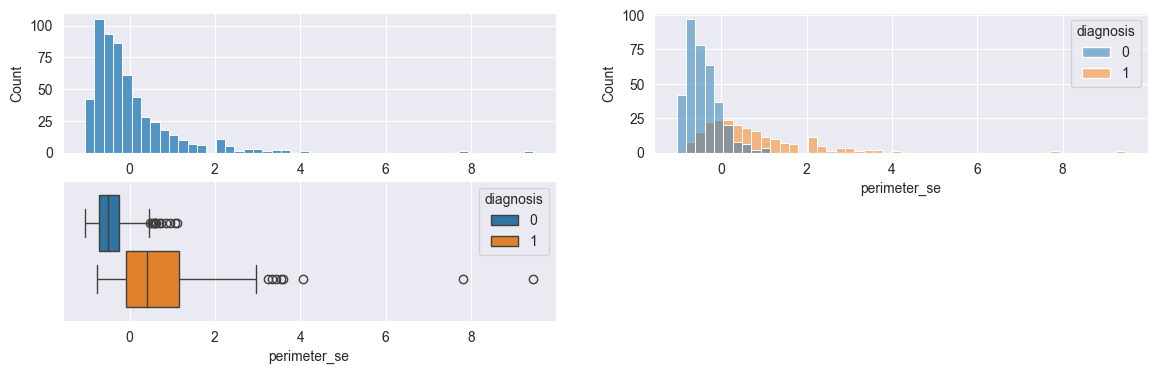

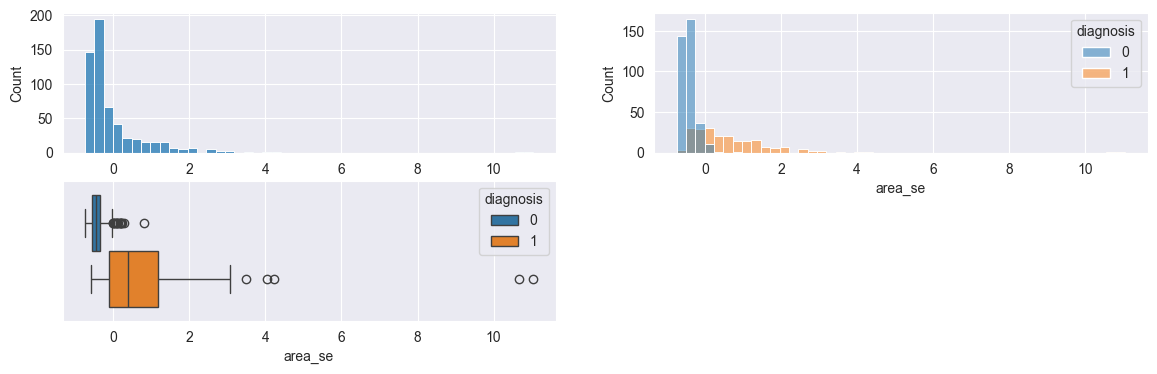

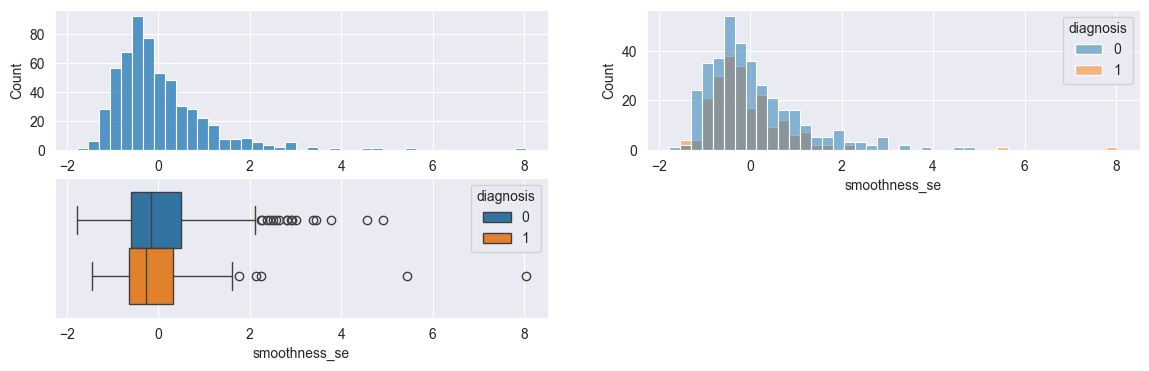

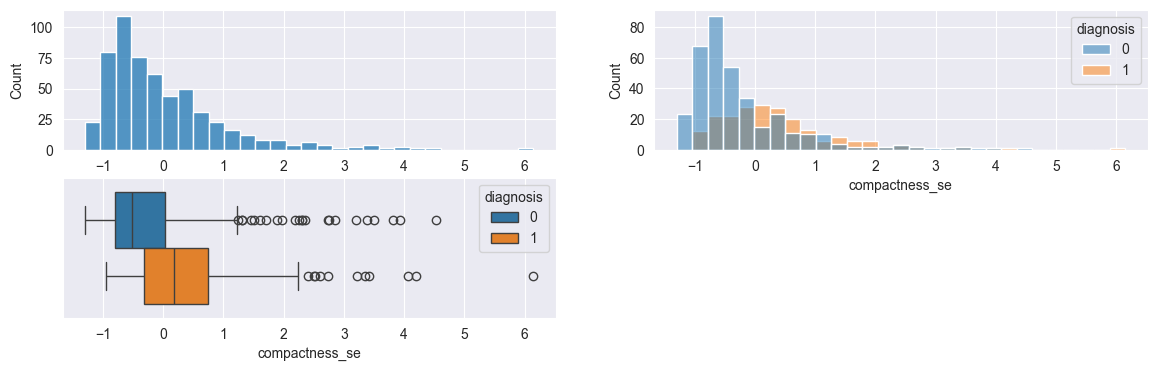

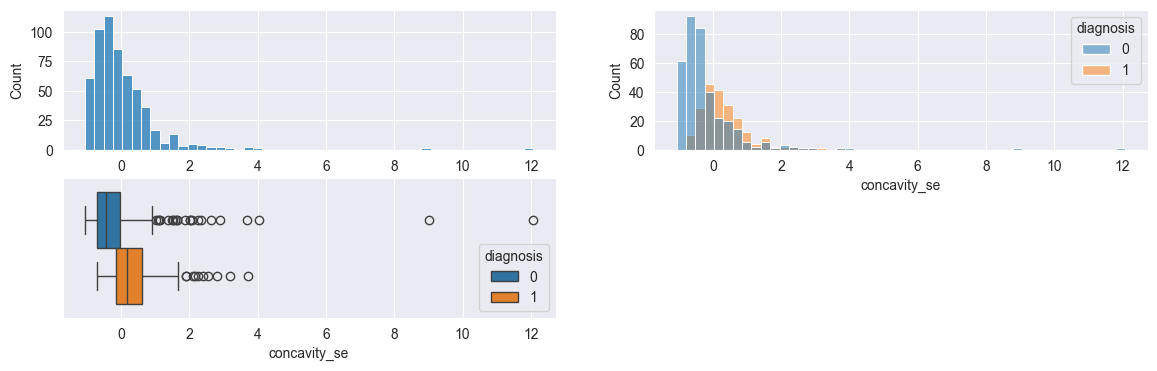

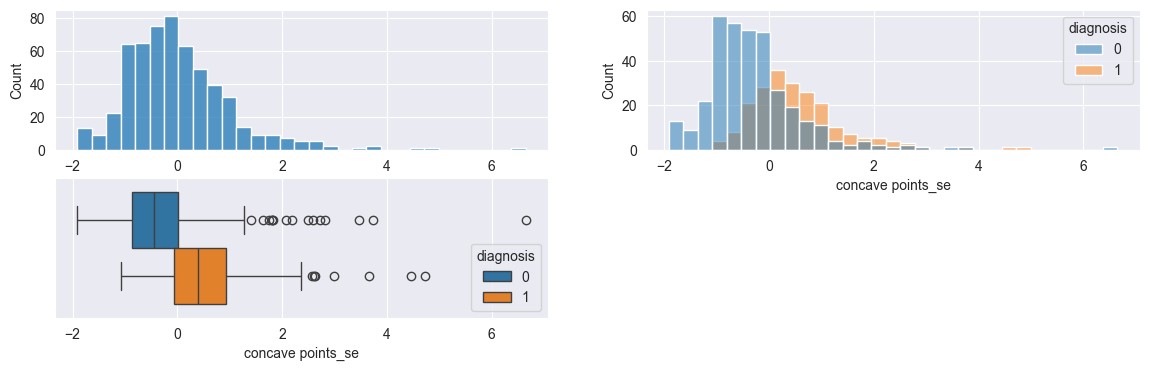

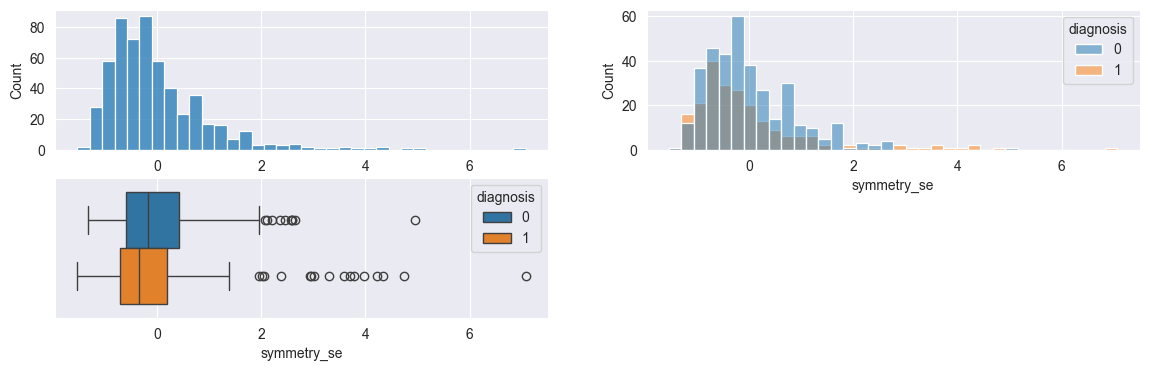

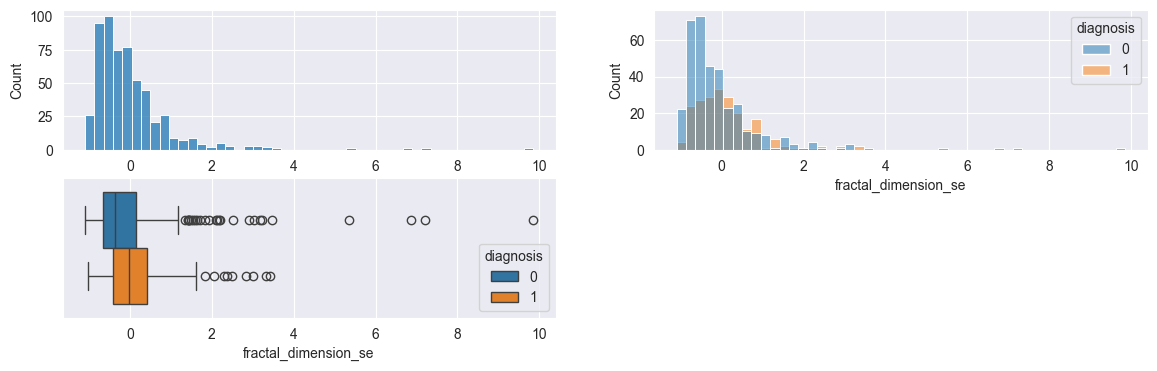

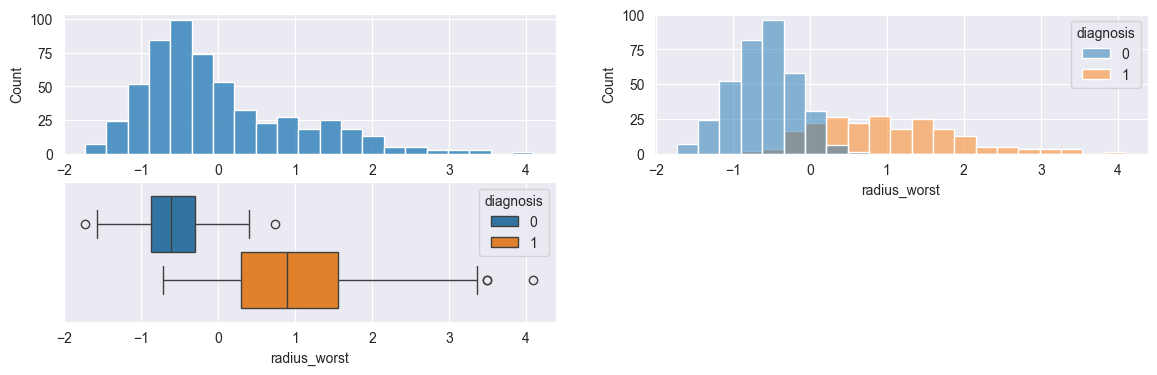

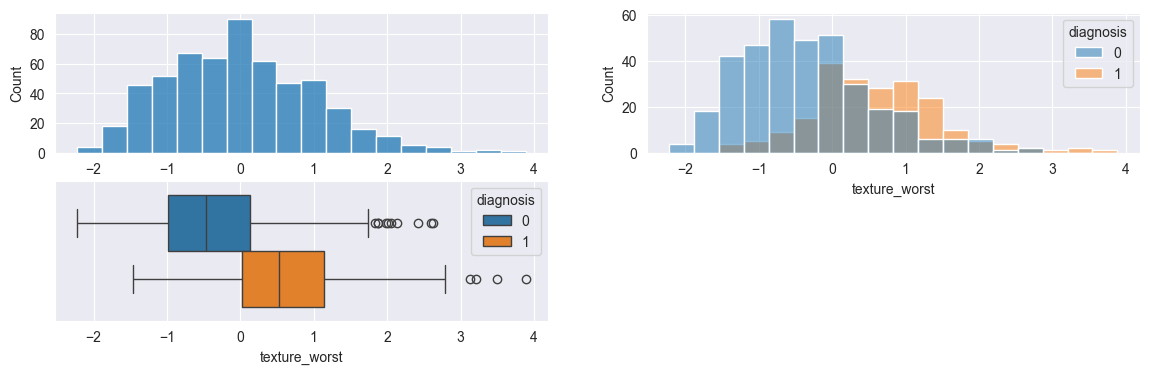

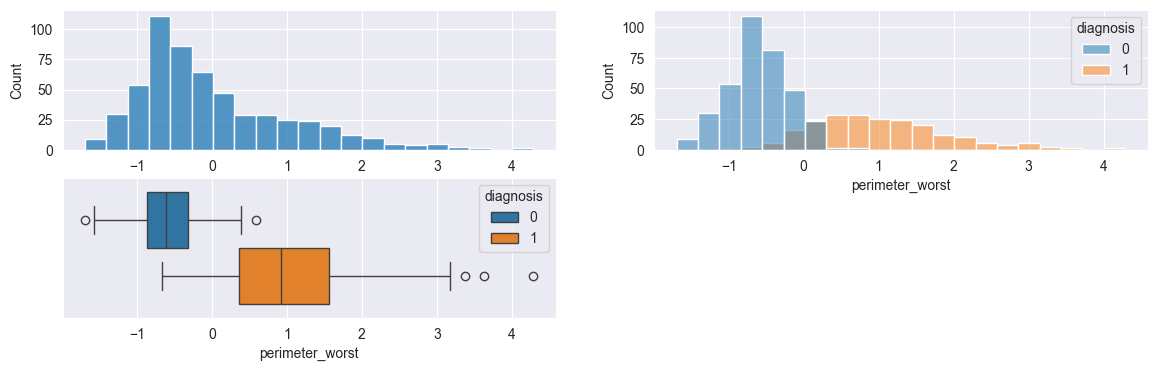

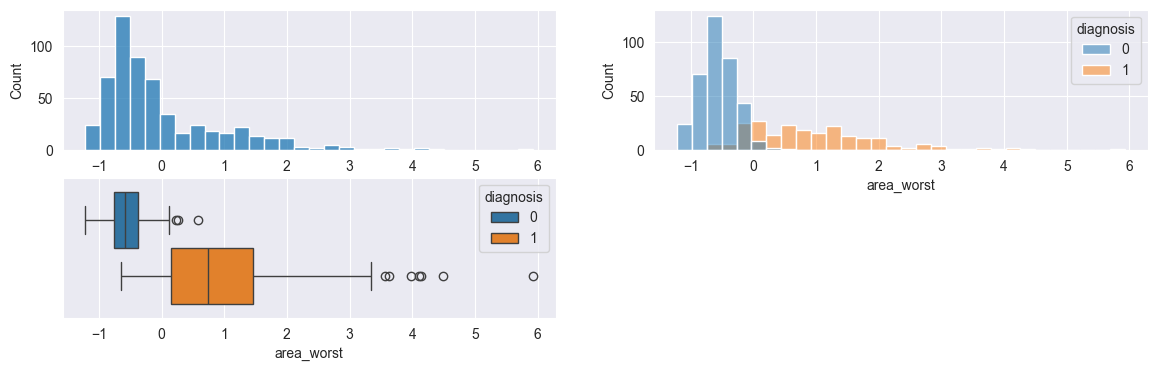

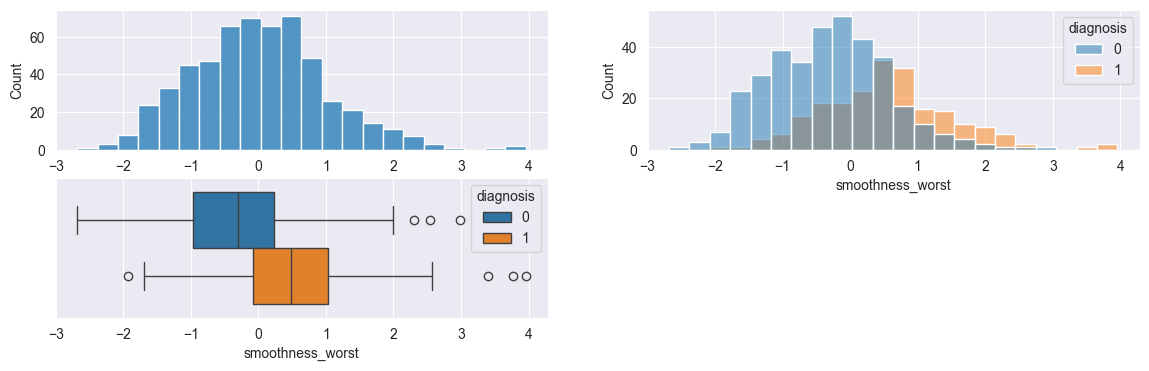

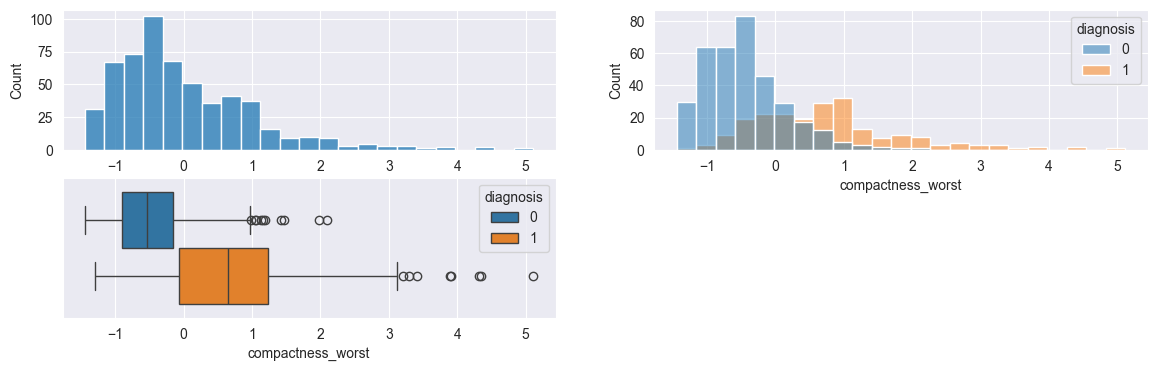

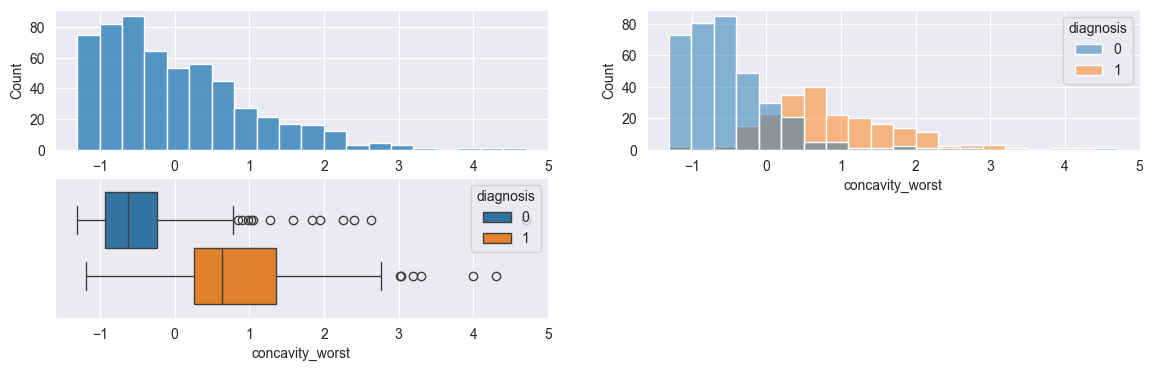

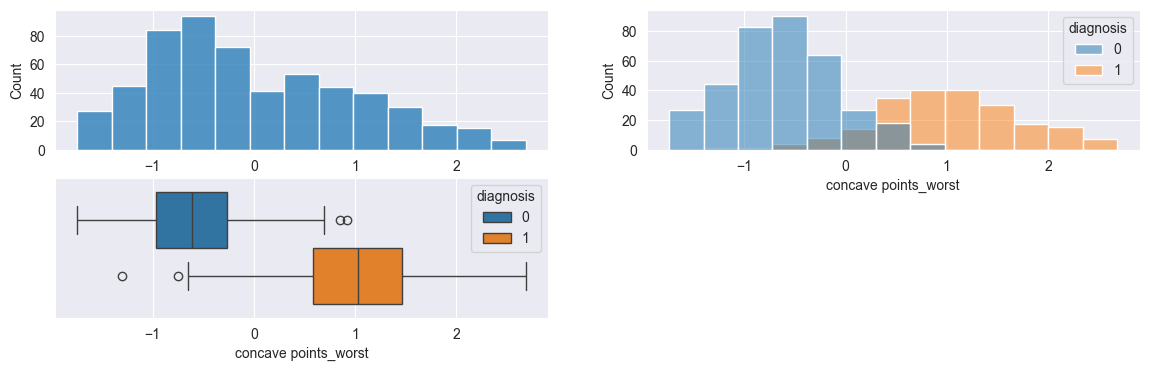

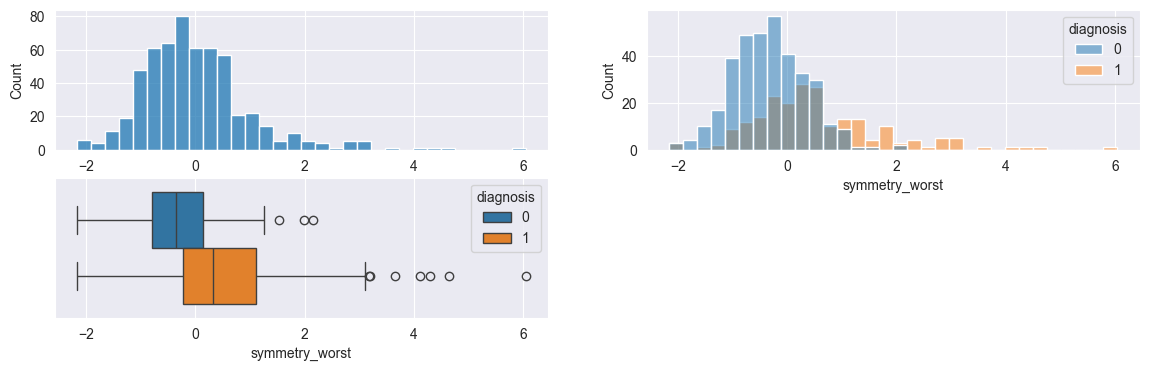

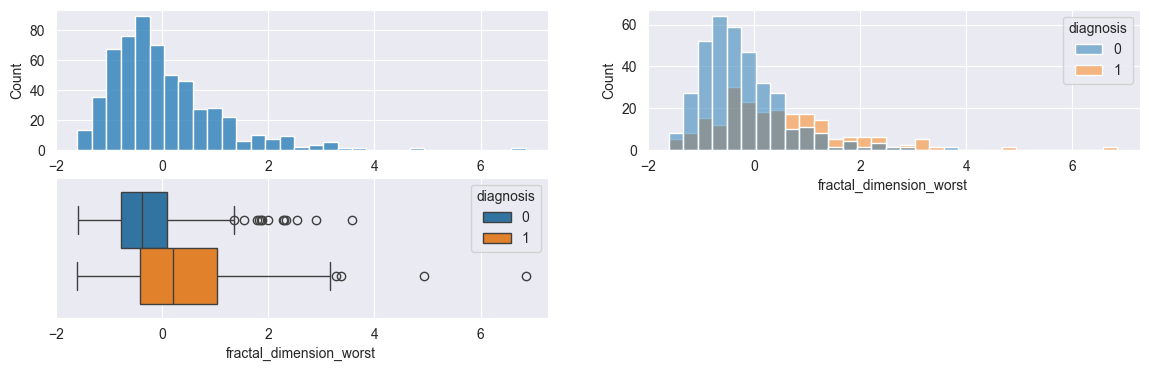

In [51]:
# Distribution and boxplot for each feature, split by target class
for col in df1_scaled.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(2,2,1)
    sns.histplot(data=df1_scaled, x=col)
    plt.subplot(2,2,2)
    sns.histplot(data=df1_scaled, x=col, hue=y)
    plt.subplot(2,2,3)
    sns.boxplot(data=df1_scaled, x=col, hue=y)
    plt.show() 

Outliers are present but are kept intentionally: in this clinical context extreme values often co-occur with malignant cases, making them informative rather than noise. With only 569 records, removing any rows would further reduce an already small sample.

### Iterative feature selection (VIF-based)

**Strategy:** Remove one feature at a time in order of decreasing VIF until all remaining features satisfy VIF < 10. Among correlated size proxies, the *worst* variants are preferred because they capture the most extreme nucleus behaviour, which is clinically more discriminative.

In [52]:
# Round 1: remove redundant size proxies
# Radius and perimeter are near-perfect linear functions of each other and of area. Keeping only 'area' 
# (both _mean and _worst blocks) removes the worst collinearity

drop_r1 = ['radius_mean', 'radius_worst', 'perimeter_mean', 'perimeter_worst']
X_sel = df1_scaled.drop(columns=drop_r1)

for ii, col in enumerate(X_sel.columns):
    vif = variance_inflation_factor(X_sel.values, ii)
    print(f"{col}: {vif:.2f}")

texture_mean: 11.68
area_mean: 28.53
smoothness_mean: 7.91
compactness_mean: 28.75
concavity_mean: 64.65
concave points_mean: 59.82
symmetry_mean: 4.07
fractal_dimension_mean: 12.72
radius_se: 36.05
texture_se: 4.04
perimeter_se: 31.23
area_se: 21.00
smoothness_se: 3.89
compactness_se: 15.20
concavity_se: 14.77
concave points_se: 10.34
symmetry_se: 5.01
fractal_dimension_se: 9.30
texture_worst: 18.00
area_worst: 23.31
smoothness_worst: 10.62
compactness_worst: 34.25
concavity_worst: 31.67
concave points_worst: 34.14
symmetry_worst: 9.08
fractal_dimension_worst: 18.29


In [53]:
# Rounds 2: iterative removal until VIF < 10 for all features
# Features dropped (each iteration chose the highest-VIF column): concavity_mean, radius_se, 
# compactness_worst, concave points_worst, area_mean, compactness_mean, texture_worst, area_se, 
# concavity_worst

drop_iter = [
    'radius_mean', 'radius_worst', 'perimeter_mean', 'perimeter_worst',
    'concavity_mean', 'radius_se', 'compactness_worst', 'concave points_worst',
    'area_mean', 'compactness_mean', 'texture_worst', 'area_se', 'concavity_worst'
]

X_m1 = df1_scaled.drop(columns=drop_iter)

for ii, col in enumerate(X_m1.columns):
    vif = variance_inflation_factor(X_m1.values, ii)
    print(f"{col}: {vif:.2f}")

# Fit Model 1 — baseline for feature selection
X_m1_const = sm.add_constant(X_m1)
res_m1 = sm.Logit(y, X_m1_const).fit()
print(res_m1.summary())

texture_mean: 1.70
smoothness_mean: 6.62
concave points_mean: 8.98
symmetry_mean: 3.65
fractal_dimension_mean: 7.17
texture_se: 2.01
perimeter_se: 4.31
smoothness_se: 3.24
compactness_se: 5.89
concavity_se: 3.97
concave points_se: 4.44
symmetry_se: 4.31
fractal_dimension_se: 5.73
area_worst: 8.68
smoothness_worst: 8.37
symmetry_worst: 7.26
fractal_dimension_worst: 8.49
Optimization terminated successfully.
         Current function value: 0.053062
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      551
Method:                           MLE   Df Model:                           17
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.9196
Time:                        19:28:15   Log-Likelihood:                -30.192
converged:                       True   LL-Null:   

In [54]:
# Remove features with p-value > 0.05 
drop_pval = [
    'smoothness_mean', 'symmetry_mean', 'concave points_se', 'symmetry_se',
    'smoothness_se', 'texture_se', 'fractal_dimension_mean',
    'fractal_dimension_se', 'fractal_dimension_worst'
]
X_m2 = X_m1.drop(columns=drop_pval)

X_m2_const = sm.add_constant(X_m2)
res_m2 = sm.Logit(y, X_m2_const).fit()
print(res_m2.summary())

Optimization terminated successfully.
         Current function value: 0.061976
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      560
Method:                           MLE   Df Model:                            8
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.9061
Time:                        19:28:16   Log-Likelihood:                -35.264
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                9.203e-142
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.0517      0.468      2.245      0.025       0.134       1.970
t

In [55]:
# Tighten VIF threshold to < 5; final feature set
# Dropping 'concave points_mean' brings all VIFs below 5
drop_final = drop_iter + drop_pval + ['concave points_mean']
X_final = df1_scaled.drop(columns=drop_final)

for ii, col in enumerate(X_final.columns):
    vif = variance_inflation_factor(X_final.values, ii)
    print(f"{col}: {vif:.2f}")

texture_mean: 1.16
perimeter_se: 2.66
compactness_se: 3.21
concavity_se: 2.81
area_worst: 2.51
smoothness_worst: 1.36
symmetry_worst: 1.42


### Final model
Model 3 was selected as the reference because it achieves the highest Pseudo R² and log-likelihood among the four candidates explored, with all coefficients statistically significant (p < 0.05).

In [56]:
X_final_const = sm.add_constant(X_final)
model_A = sm.Logit(y, X_final_const)
results_A = model_A.fit()
print(results_A.summary())

Optimization terminated successfully.
         Current function value: 0.068263
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      561
Method:                           MLE   Df Model:                            7
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.8966
Time:                        19:28:16   Log-Likelihood:                -38.841
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                3.132e-141
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.2073      0.455      2.651      0.008       0.315       2.100
texture_me

### Cross-validation (5-fold, ROC-AUC)

In [57]:
lr_A = LogisticRegression(random_state=seed, max_iter=1000)
cv_scores_A = cross_val_score(lr_A, X_final, y, cv=5, scoring='roc_auc')

print(f"ROC-AUC per fold: {cv_scores_A.round(4)}")
print(f"Mean: {cv_scores_A.mean():.4f}  |  Std: {cv_scores_A.std():.4f}")
# Low variance across folds indicates the model generalises well and is not overfitting despite the high Pseudo R²

ROC-AUC per fold: [0.981  0.9944 0.9997 0.9825 0.9977]
Mean: 0.9910  |  Std: 0.0078


### Odds ratios with 95% confidence intervals

In [58]:
# Re-fit to get statsmodels confidence intervals
results_A_final = sm.Logit(y, X_final_const).fit()

ci = results_A_final.conf_int()
ci.columns = ['CI_lower', 'CI_upper']

or_table = pd.DataFrame({
    "Coefficient": results_A_final.params,
    "Odds Ratio": np.exp(results_A_final.params),
    "CI_lower (exp)": np.exp(ci['CI_lower']),
    "CI_upper (exp)": np.exp(ci['CI_upper']),
    "p-value": results_A_final.pvalues
}).drop('const').round(3)

print(or_table.to_string())

Optimization terminated successfully.
         Current function value: 0.068263
         Iterations 11
                  Coefficient  Odds Ratio  CI_lower (exp)  CI_upper (exp)  p-value
texture_mean            1.969       7.166           3.163          16.234    0.000
perimeter_se            2.634      13.933           3.500          55.474    0.000
compactness_se         -1.344       0.261           0.094           0.727    0.010
concavity_se            0.952       2.592           1.315           5.108    0.006
area_worst             10.533   37525.727        1200.556     1172940.357    0.000
smoothness_worst        2.518      12.407           4.683          32.871    0.000
symmetry_worst          1.354       3.873           1.824           8.226    0.000


**Key findings — Model A**

- **Pseudo R² = 0.897** with a mean cross-validated **ROC-AUC = 0.99** (5-fold), low variance — the model is stable and not overfitting.
- `area_worst` is the strongest positive predictor: each standard-deviation increase multiplies the odds of malignancy by ~37.5, confirming that tumour size in the most extreme nuclei is the dominant signal.
- Features with OR > 1 (`texture_mean`, `perimeter_se`, `concavity_se`, `smoothness_worst`, `symmetry_worst`) all point to greater size, roughness, and variability in the worst nuclei being associated with malignancy.
- `compactness_se` is the only protective factor (OR < 1): higher variability in compactness across nuclei is associated with benign diagnosis.


## 3. Model B : PCA Components

### Exploratory PCA — scree plot and explained variance

[27-06-2026 19:28:16] [pca.pca] [INFO] Extracting column labels from dataframe.
[27-06-2026 19:28:16] [pca.pca] [INFO] Extracting row labels from dataframe.
[27-06-2026 19:28:16] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 30 columns of the input data.
[27-06-2026 19:28:16] [pca.pca] [INFO] Fit using PCA.
[27-06-2026 19:28:16] [pca.pca] [INFO] Compute loadings and PCs.
[27-06-2026 19:28:16] [pca.pca] [INFO] Compute explained variance.
[27-06-2026 19:28:16] [pca.pca] [INFO] The top 10 principal component(s) explains >= 95.00% of the explained variance.
[27-06-2026 19:28:16] [pca.pca] [INFO] The PCA reduction is performed on 30 variables (columns) of the input dataframe.
[27-06-2026 19:28:16] [pca.pca] [INFO] Fit using PCA.
[27-06-2026 19:28:16] [pca.pca] [INFO] Compute loadings and PCs.
[27-06-2026 19:28:16] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[10]
[27-06-2026 19:28:17] [pca.pca] [I

<Figure size 900x400 with 0 Axes>

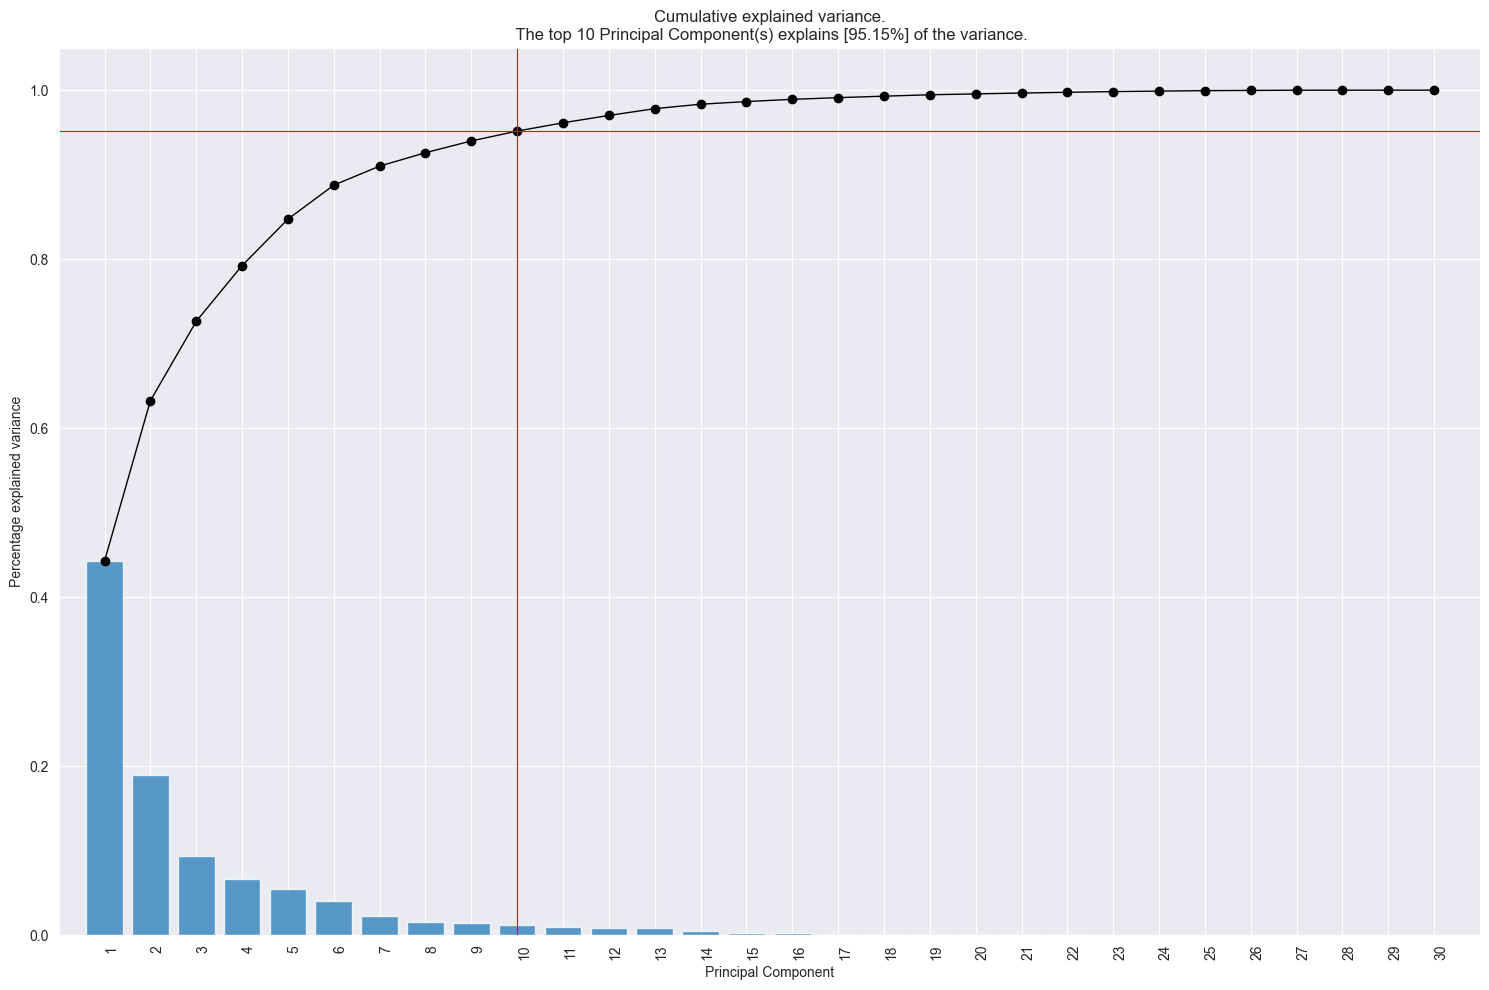

  PC  explained_var_cumulative  variance_ratio
 PC1                     0.443           0.443
 PC2                     0.632           0.190
 PC3                     0.726           0.094
 PC4                     0.792           0.066
 PC5                     0.847           0.055
 PC6                     0.888           0.040
 PC7                     0.910           0.023
 PC8                     0.926           0.016
 PC9                     0.940           0.014
PC10                     0.952           0.012
PC11                     0.961           0.010
PC12                     0.970           0.009
PC13                     0.978           0.008
PC14                     0.983           0.005
PC15                     0.986           0.003
PC16                     0.989           0.003
PC17                     0.991           0.002
PC18                     0.993           0.002
PC19                     0.995           0.002
PC20                     0.996           0.001
PC21         

In [59]:
# Full PCA (all 30 components) to choose how many to retain
pca_explorer = pca()
pca_out = pca_explorer.fit_transform(df1_scaled)

plt.figure(figsize=(9, 4))
pca_explorer.plot()
plt.tight_layout()
plt.show()

# Tabular view of cumulative explained variance
ev_df = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, 31)],
    'explained_var_cumulative': pca_out['explained_var'],
    'variance_ratio': pca_out['variance_ratio']
}).round(3)
print(ev_df.to_string(index=False))

### Dimensionality reduction
**Decision: retain 6 components (≈89% of total variance).**  
The 7th component adds only ~2% more variance, well below the marginal gain of the first six. Six components is therefore a reasonable elbow point.

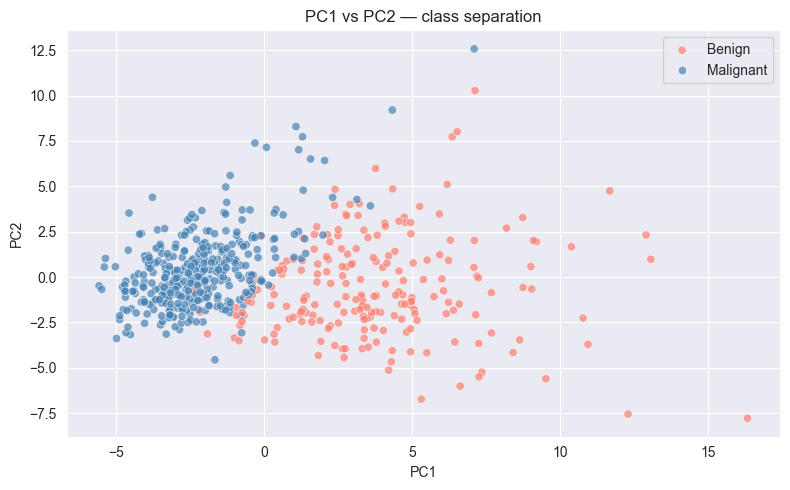

In [60]:
pca_6 = PCA(n_components=6, random_state=seed)
X_pca = pca_6.fit_transform(df1_scaled)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(6)])
df_pca['diagnosis'] = y.values

# Scatter plot: does PC1 vs PC2 separate the classes?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='diagnosis',
                palette={0: 'steelblue', 1: 'salmon'}, alpha=0.7)
plt.legend(labels=['Benign', 'Malignant'])
plt.title("PC1 vs PC2 — class separation")
plt.tight_layout()
plt.show()

# PC1 and PC2 together provide a clean visual separation between classes.

### Logistic regression on PCA components

In [61]:
# Full 6-component model
X_pca_6 = df_pca.drop(columns='diagnosis')
X_pca_6_const = sm.add_constant(X_pca_6)

res_pca_full = sm.Logit(y, X_pca_6_const).fit()
print(res_pca_full.summary())

Optimization terminated successfully.
         Current function value: 0.069963
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      562
Method:                           MLE   Df Model:                            6
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.8940
Time:                        19:28:18   Log-Likelihood:                -39.809
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                7.409e-142
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4619      0.310     -1.490      0.136      -1.070       0.146
PC1            3.0864      0

In [62]:
# PC6 is not significant (p > 0.05) — remove it
X_pca_5 = df_pca.drop(columns=['diagnosis', 'PC6'])
X_pca_5_const = sm.add_constant(X_pca_5)

results_B = sm.Logit(y, X_pca_5_const).fit()
print(results_B.summary())

Optimization terminated successfully.
         Current function value: 0.073284
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      563
Method:                           MLE   Df Model:                            5
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.8890
Time:                        19:28:18   Log-Likelihood:                -41.698
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                3.983e-142
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4137      0.312     -1.326      0.185      -1.025       0.198
PC1            2.8911      0

### Cross-validation (5-fold, ROC-AUC)

In [63]:
lr_B = LogisticRegression(random_state=seed, max_iter=1000)
cv_scores_B = cross_val_score(lr_B, X_pca_5, y, cv=5, scoring='roc_auc')

print(f"ROC-AUC per fold: {cv_scores_B.round(4)}")
print(f"Mean: {cv_scores_B.mean():.4f}  |  Std: {cv_scores_B.std():.4f}")

ROC-AUC per fold: [0.9964 0.9954 0.9954 0.9874 0.9997]
Mean: 0.9949  |  Std: 0.0040


### Component interpretation — loadings and Odds Ratios

In [64]:
loadings = pd.DataFrame(
    pca_6.components_.T,
    index=df1_scaled.columns,
    columns=[f'PC{i+1}' for i in range(6)]
)
# Sort by PC1 loading to see which features drive the first component
print(loadings[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']].sort_values('PC1', ascending=False).round(3).to_string())

                           PC1    PC2    PC3    PC4    PC5
concave points_mean      0.261 -0.035 -0.026 -0.065  0.044
concavity_mean           0.258  0.060  0.003 -0.019 -0.086
concave points_worst     0.251 -0.008 -0.170 -0.006 -0.043
compactness_mean         0.239  0.152 -0.074 -0.032 -0.012
perimeter_worst          0.237 -0.200 -0.049 -0.014 -0.007
concavity_worst          0.229  0.098 -0.173  0.074 -0.189
radius_worst             0.228 -0.220 -0.048 -0.015  0.004
perimeter_mean           0.228 -0.215 -0.009 -0.042 -0.037
area_worst               0.225 -0.219 -0.012 -0.026  0.027
area_mean                0.221 -0.231  0.029 -0.053 -0.010
radius_mean              0.219 -0.234 -0.009 -0.041 -0.038
perimeter_se             0.211 -0.089  0.267 -0.089  0.121
compactness_worst        0.210  0.144 -0.236  0.091 -0.122
radius_se                0.206 -0.106  0.268 -0.098  0.154
area_se                  0.203 -0.152  0.216 -0.108  0.128
concave points_se        0.183  0.130  0.225 -0.074 -0.1

In [65]:
# Odds ratios for the PCA-based model
or_table_B = pd.DataFrame({
    "Coefficient": results_B.params,
    "Odds Ratio": np.exp(results_B.params),
}).drop('const').round(3)
print(or_table_B.to_string())

     Coefficient  Odds Ratio
PC1        2.891      18.013
PC2       -1.592       0.204
PC3       -0.499       0.607
PC4        0.784       2.191
PC5        1.281       3.599


**Key findings — Model B**
- **Pseudo R² = 0.889**, mean cross-validated **ROC-AUC = 0.994** — comparable to Model A, confirming that 5 principal components capture nearly all the discriminative information.
- **PC1** (OR ≈ 18): the dominant predictor. Loaded by `concave_points_mean`, `concavity_mean`, and worst-block size features — it encodes overall tumour irregularity and size. Larger, more irregular nuclei push this component up and are strongly associated with malignancy.
- **PC2** (OR < 1, protective): driven by `fractal_dimension` features (positive loadings) while size features load negatively. Tumours with high fractal complexity but not enlarged nuclei tend to be benign.
- **PC3** (OR < 1, protective): captures variability in texture, smoothness, and symmetry across nuclei. Greater across-nucleus heterogeneity is associated with benign diagnosis.
- **PC4 and PC5** are significant but weaker positive predictors, linked to texture (PC4) and smoothness (PC5) of the worst nuclei.

### Threshold Optimisation (Model B)
The default decision threshold (0.5) is not necessarily optimal for accuracy. A simple grid search over [0, 1] identifies whether a different cut-off improves classification on the full dataset.

In [66]:
y_hat_probs = results_B.predict(X_pca_5_const)
y_hat_05 = (y_hat_probs >= 0.5).astype(int)

acc_50 = accuracy_score(y, y_hat_05)
print(f"Accuracy at threshold 0.50: {acc_50:.4f}")

# Grid search
improvements = []
for t in np.arange(0.01, 1.0, 0.01):
    acc = accuracy_score(y, (y_hat_probs >= t).astype(int))
    if acc > acc_50:
        improvements.append((round(t, 2), round(acc, 4)))

if improvements:
    print("Thresholds that improve accuracy:")
    for t, a in improvements:
        print(f"  threshold={t:.2f}  →  accuracy={a:.4f}")
else:
    print("Default threshold (0.50) is already optimal")

Accuracy at threshold 0.50: 0.9772
Thresholds that improve accuracy:
  threshold=0.49  →  accuracy=0.9789
  threshold=0.51  →  accuracy=0.9789
  threshold=0.52  →  accuracy=0.9789


In [67]:
# Apply best threshold (0.49)
best_threshold = 0.49
y_hat_final = (y_hat_probs >= best_threshold).astype(int)
print(f"Final accuracy at threshold {best_threshold}: {accuracy_score(y, y_hat_final):.4f}")

Final accuracy at threshold 0.49: 0.9789


## 4. Summary

| | Model A (Raw Features) | Model B (PCA) |
|---|---|---|
| Features used | 7 selected (VIF < 5, p < 0.05) | 5 principal components |
| Pseudo R² | 0.897 | 0.889 |
| CV ROC-AUC (mean) | 0.990 | 0.994 |
| Interpretability | Direct (odds ratios per feature) | Indirect (loadings → OR) |
| Multicollinearity | Eliminated via VIF selection | Eliminated by construction |

Both approaches yield models with excellent fit and stable cross-validation performance. Model A is more directly interpretable at the individual-feature level, while Model B provides a compact and fully orthogonal representation that may generalise better when the feature space is extended.